In [2]:
import pandas as pd
import numpy as np

In [3]:

# ==========================================
# 1. Load your data
# ==========================================
try:
    eevdf_single = pd.read_csv("eevdf_baseline_singlecpu_metrics.csv")
    scx_single   = pd.read_csv("scx_simple_singlecpu_metrics.csv")
    
    eevdf_all    = pd.read_csv("eevdf_baseline_metrics.csv")
    scx_all      = pd.read_csv("scx_simple_metrics.csv")
except FileNotFoundError as e:
    print(f"Error loading file: {e}\nPlease check your filenames!")
    raise

In [4]:
# ==========================================
# 2. Average the 5 Runs
# ==========================================
def average_the_runs(df, name):
    # 1. Drop the warm-up run
    if 'Run' in df.columns and df['Run'].dtype == object:
        clean_df = df[~df['Run'].astype(str).str.contains("Warm-up", na=False)]
    else:
        clean_df = df
        
    # 2. Average the remaining 5 runs together
    averaged_metrics = clean_df.mean(numeric_only=True)
    
    # 3. Print the results for the presentation slides
    print(f"--- Averaged Results for 5 Runs: {name} ---")
    print(f"  Avg Fairness (Std Dev): {averaged_metrics['Std_Dev_s']:.4f} seconds")
    print(f"  Avg Latency:            {averaged_metrics['Avg_Latency_s']:.4f} seconds")
    print(f"  Avg Throughput:         {averaged_metrics['Throughput_tps']:.2f} tps")
    print(f"  Avg Context Switches:   {averaged_metrics['Total_Context_Switches']:,.0f}\n")
    
    return averaged_metrics

# Calculate and print the averages for all 4 datasets
means_eevdf_s = average_the_runs(eevdf_single, "EEVDF (Single CPU)")
means_scx_s   = average_the_runs(scx_single, "SCX_Simple (Single CPU)")
means_eevdf_a = average_the_runs(eevdf_all, "EEVDF (All 40 CPUs)")
means_scx_a   = average_the_runs(scx_all, "SCX_Simple (All 40 CPUs)")

--- Averaged Results for 5 Runs: EEVDF (Single CPU) ---
  Avg Fairness (Std Dev): 0.0037 seconds
  Avg Latency:            122.2392 seconds
  Avg Throughput:         0.16 tps
  Avg Context Switches:   37,040

--- Averaged Results for 5 Runs: SCX_Simple (Single CPU) ---
  Avg Fairness (Std Dev): 0.0611 seconds
  Avg Latency:            121.7974 seconds
  Avg Throughput:         0.16 tps
  Avg Context Switches:   6,178

--- Averaged Results for 5 Runs: EEVDF (All 40 CPUs) ---
  Avg Fairness (Std Dev): 0.5907 seconds
  Avg Latency:            17.4584 seconds
  Avg Throughput:         3.05 tps
  Avg Context Switches:   375,672

--- Averaged Results for 5 Runs: SCX_Simple (All 40 CPUs) ---
  Avg Fairness (Std Dev): 0.0935 seconds
  Avg Latency:            19.0297 seconds
  Avg Throughput:         3.10 tps
  Avg Context Switches:   61,531



In [5]:
!pip install --upgrade matplotlib ipython --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


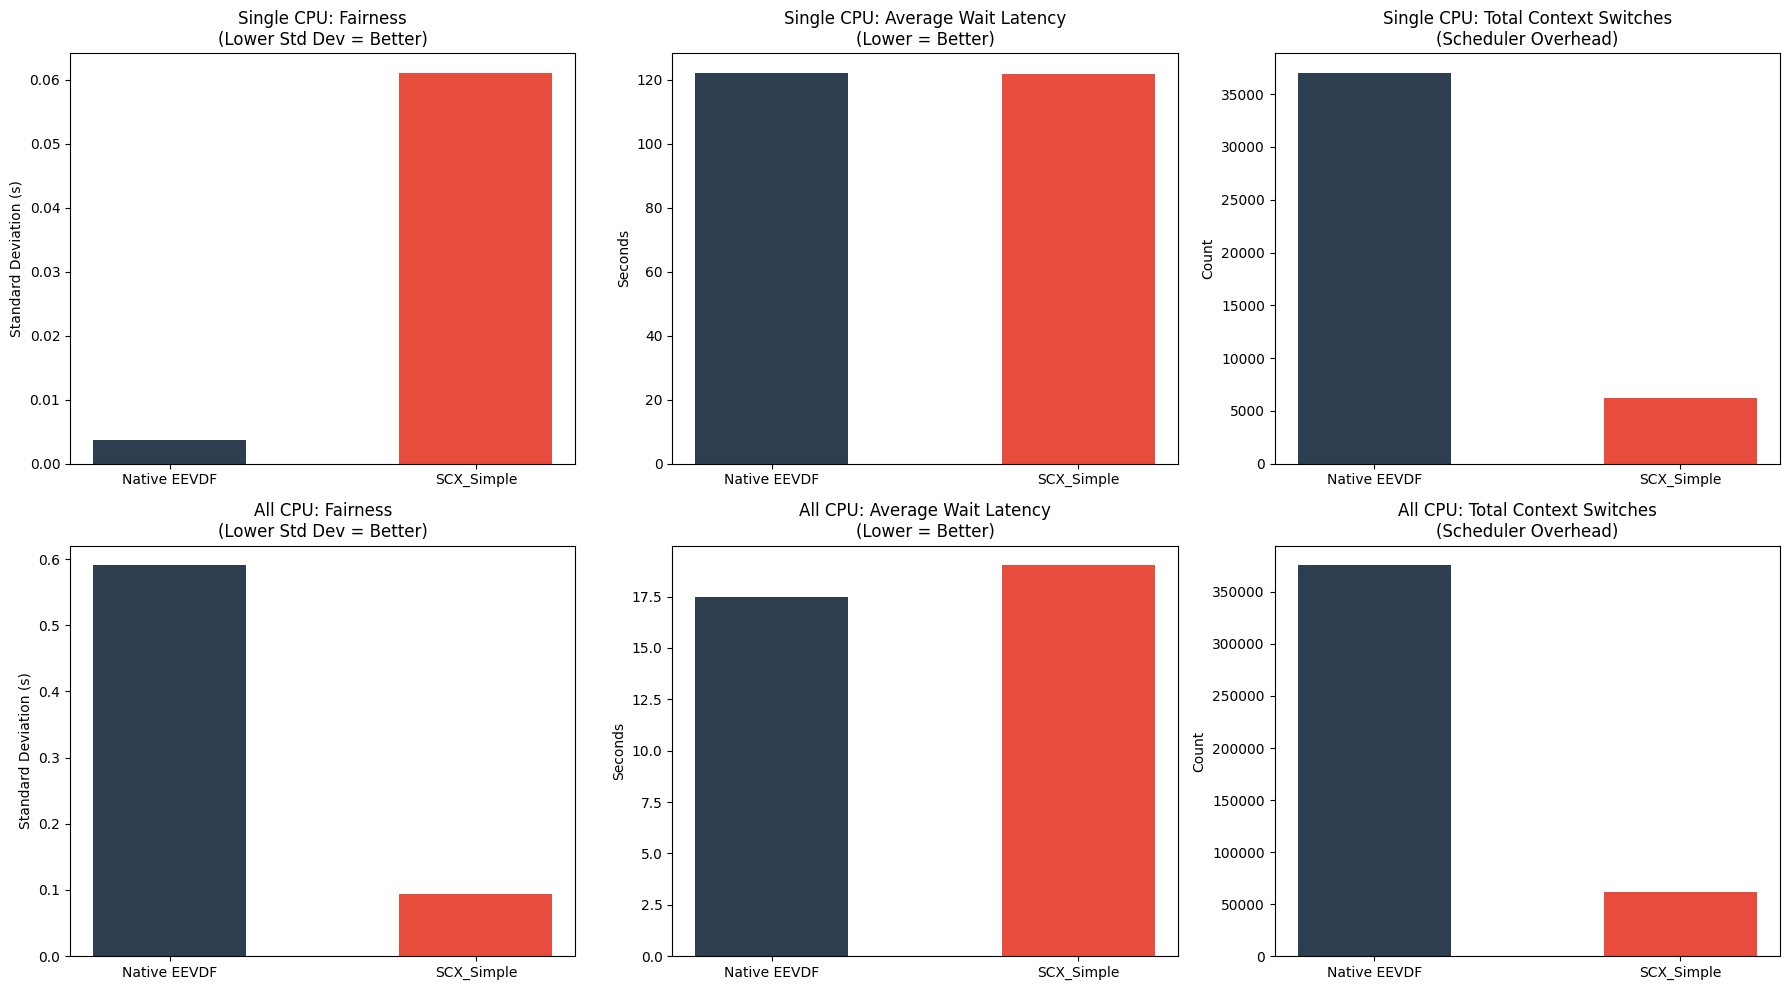

In [6]:
import matplotlib.pyplot as plt
# ==========================================
# 3. Plotting the Averaged Data
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# fig.suptitle('Linux Native EEVDF vs. eBPF scx_simple (-v)\n(Data represents the average of 5 benchmark runs)', fontsize=18, fontweight='bold', y=1.02)

color_native = '#2c3e50'
color_ebpf   = '#e74c3c'
labels = ['Native EEVDF', 'SCX_Simple']
width = 0.5

# --- ROW 1: SINGLE CPU CONTENTION ---
axes[0, 0].bar(labels, [means_eevdf_s['Std_Dev_s'], means_scx_s['Std_Dev_s']], color=[color_native, color_ebpf], width=width)
axes[0, 0].set_title('Single CPU: Fairness\n(Lower Std Dev = Better)')
axes[0, 0].set_ylabel('Standard Deviation (s)')

axes[0, 1].bar(labels, [means_eevdf_s['Avg_Latency_s'], means_scx_s['Avg_Latency_s']], color=[color_native, color_ebpf], width=width)
axes[0, 1].set_title('Single CPU: Average Wait Latency\n(Lower = Better)')
axes[0, 1].set_ylabel('Seconds')

axes[0, 2].bar(labels, [means_eevdf_s['Total_Context_Switches'], means_scx_s['Total_Context_Switches']], color=[color_native, color_ebpf], width=width)
axes[0, 2].set_title('Single CPU: Total Context Switches\n(Scheduler Overhead)')
axes[0, 2].set_ylabel('Count')

# --- ROW 2: ALL CPU (NUMA) CONTENTION ---
axes[1, 0].bar(labels, [means_eevdf_a['Std_Dev_s'], means_scx_a['Std_Dev_s']], color=[color_native, color_ebpf], width=width)
axes[1, 0].set_title('All CPU: Fairness\n(Lower Std Dev = Better)')
axes[1, 0].set_ylabel('Standard Deviation (s)')

axes[1, 1].bar(labels, [means_eevdf_a['Avg_Latency_s'], means_scx_a['Avg_Latency_s']], color=[color_native, color_ebpf], width=width)
axes[1, 1].set_title('All CPU: Average Wait Latency\n(Lower = Better)')
axes[1, 1].set_ylabel('Seconds')

axes[1, 2].bar(labels, [means_eevdf_a['Total_Context_Switches'], means_scx_a['Total_Context_Switches']], color=[color_native, color_ebpf], width=width)
axes[1, 2].set_title('All CPU: Total Context Switches\n(Scheduler Overhead)')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()